<center>
    <p>115 Theoretical Neuroscience II</p>
    <h1></h1>
    <h1>Lecture 13:</h1>
    <h1>Causal Models</h1>
    <p>----</p>
    <p>Prof. Jochen Braun Ph.D.</p>
    <p>Institute of Biology</p>
    <p>Otto-von-Guericke University Magdeburg</p>
    <p>----</p>
    <p>Textbook:</p>
    <p>Peter Dayan & Larry Abbott (2001) Theoretical Neuroscience, MIT Press.</p>
    <p> Jonathan Schlens (2005) "A Tutorial on Principal Component Analysis</p>
</center>

In [ ]:
from IPython.display import display, Math

# Inject custom MathJax configuration for additional packages
custom_latex = r"""
\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{eufrak}
"""

# **Abstract:**

How can a brain 'understand' its environment?  What would such an 'understanding' involve?

<br>

**Causal models** offer plausible answers.  External causes (true, physical) produce sensations (observations).  Brains try to explain observed sensations in terms of internal causes (hypothetical, latent).

<br>

A causal model has two sides: **generative formulation** computes probability of observation (conditional, given one cause, and marginal, given all causes), **recognition formulation** computes likelihood of causes (conditional, given one observation, and marginal, given all observations).   Causal models are improved iteratively, by considering the same observations again and again: **expectation step** assigns to observations probability of causes,
**maximization step** recomputes the generative model for causes (mean, variance of associated observations …).  

<br>

We illustrate iterative improvement of causal models for **K-means** and for **expectation-maximization** algorithm.  Causal models improve in a 'hermeneutic circle'!

<br>

# **Overview:**

**1 Introduction to causal models**

**2 Improving causal models**

**3 K-means**

**4 Expectation maximization (EM)**

**5 Factor analysis**



# **1. Introduction to causal models**

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_01.png" width="600">

We wish to understand complex observations (sensations) in terms of few model causes (which ideally approximate 'true' causes).

Possible sources (causes) of sounds in a forest.

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_01b.png" width="600">



# Features of sound spectrogram

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_01c.png" width="600">


Pitch: fundamental frequency and overtones.  Formant: shaping of amplitude.

# Features of sound spectrogram, ctd

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_01d.png" width="600">



# Auditory feature space (schematic)

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_02a.png" width="600">

# Sounds from a mouse

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_02b.png" width="600">


<br>


# Sounds from a fox

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_02c.png" width="600">

<br>



# Sounds from wind

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_02d.png" width="600">

Different causes produce different sound features!

# Statistical distribution of sounds

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_02e.png" width="600">

<br>

Statistically, the sound features produced by different causes are distributed differently!  Ellipses indicate statistical distributions.

# One stormy night ...

... an owl hears three distinct sounds.  What might be their origin?

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_02f.png" width="600">

<br>

Exploit prior experience (statistical distributions) for 'probabilistic recognition'!  Probability of cause, given observed features.

# Generative formulation I:

<br>

Consider sensory events $\bf u$ (a vector) and their probability distribution $P(\bf u)$.  The structure of such distributions often suggests discrete underlying causes (*e.g.*, mice, foxes, wind).

<br>

A  *causal description* $G$ of such a sensory world involves two levels.  

<br>

Firstly, a *causal variable* $v$, which takes discrete values (*e.g.*, M, F, or W) corresponding to distinct environmental causes, and the associated probabilities $P(v;G)$:

<br>

$$
v \in \{ M, F, W \}, \qquad\qquad P(v;G) \in \{ \gamma_M, \gamma_F, \gamma_W\}
$$

<br>

$$
\gamma_M+\gamma_F+\gamma_W = 1
$$

# Generative formulation II:

Secondly, *generative distributions* specifying the conditional probability of a hypothetical observation $\bf u$ for each cause $v$.  These distributions describe which sounds each cause is likely to make:

<br>

$$
P({\bf u} | M; G), \qquad\qquad P({\bf u} | F; G), \qquad\qquad P({\bf u} | W; G)
$$

<br>

Typically, these generative distributions overlap.  Thus, a given observation $\bf u$ may originate from one of several possible causes $v$.  For this reason, the 'true' value of $v$ cannot be determined unambiguously.

# Generative formulation III:

<br>

Probability of causes $\gamma_X$ and generative distributions $P({\bf u} | X; G)$.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_02g.png" width="600">

# Probabilistic and deterministic recognition

In *probabilistic recognition*, we wish to know the probability that an actual observation ${\bf u}_\mathit{obs}$ was caused by cause M or F or W.  In *deterministic recognition*, we simply wish to know the most likely cause.  

<br>

$$
{\bf u}_\mathit{obs} \qquad\qquad P(M | {\bf u}_\mathit{obs}; G),  \qquad P(F | {\bf u}_\mathit{obs}; G), \qquad P(W | {\bf u}_\mathit{obs}; G)
$$

<br>

For both purposes, we need a *recognition model*:

<br>

$$
P(v|{\bf u}; G) = \frac{p({\bf u} |v;G) \, P(v;G)}{p({\bf u}; G)}
$$

<br>

In principle, such a model can be obtained by applying Bayes' rule to our *generative model* $G$.

# Recognition formulation

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_02h.png" width="600">

<br>

How likely did causes $M$, $F$, $W$ produce a given observation $\bf u_\mathit{obs}$?

# **Points to note**

<br>

- Causal models $G$ describe a sensory scene compactly in terms of model causes $X$.

<br>

- Generative formulation proceeds from model causes $X$ to predicted observations $\bf u$:

$$
P({\bf u} | X; G)
$$

<br>

- Inverting a generative formulation with Bayes' rule yields a recognition formulation.

<br>

- Recognition formulation proceeds from actual observations ${\bf u}_\mathit{obs}$ to inferred model causes $X$.
$$
P(X | {\bf u}; G)
$$


# **2. Improving causal models**


<br>

To develop a causal model $G$, we need enough observations to reveal their statistical structure.   We judge the quality of a causal model by its ability to reproduce (and thus 'explain') this structure.

<br>

The structure of a causal model reflects heuristic information (prejudices, assumptions, analogies, ...).   

<br>

Given such a structure, we consider the **same observations** again and again, to iteratively adjust the model and improve the match between observation and reproduction.

<br>

$$\begin{eqnarray}
{\rm Data \,\, vectors} \qquad&&\qquad{\bf u} = (u_1, u_2, \ldots)
\\
{\rm Scalar \,\, causes} \qquad&&\qquad   v \in \{A,B\}
\\
{\rm Generative \,\, formulation} \qquad&&\qquad   P({\bf u} | v ; G)
\\
{\rm Recognition \,\, formulation} \qquad&&\qquad   P(v | {\bf u}; G)
\end{eqnarray}$$


<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_03a.png" width="600">

Illustration from Dayan \& Abbot.

# Generative model (two Gaussian causes)

<br>

**Prior distribution of causes:**

$$
v \in \{A,B\}, \qquad\qquad P[v; G] = \gamma_v, \qquad\qquad \gamma_A+\gamma_B = 1
$$

<br>

**Generative distribution:**

$$
p[{\bf u} | v; G] = \frac{1}{2\pi\,\Sigma_{v}} \, \exp\left[-\frac{|{\bf u} - {\bf g}_v|^2 }{2 \Sigma_{v}} \right]
$$

<br>

**Parameter set:**

$$
G = \{ \gamma_A, \gamma_B, {\bf g}_A, {\bf g}_B, \Sigma_A , \Sigma_B\}
$$

<br>

**Marginal distribution:**

$$
p[{\bf u}; G] = \sum_v  \, p[{\bf u} | v; G] \, P[v;G]
$$

# Graphical convention

<br>

The 'teardrop' represents a conditional distribution of events $\bf u$ being generated from a parameter set $A$.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_03b.png" width="600">


# From cause to observation ( $\leftarrow$ )

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_03c.png" width="600">

# Recognition model

<br>

A *recognition model* classifies new observations in terms of their probable causes.  In some cases, we
can use Bayes' theorem to compute the most likely cause, given a particular observation:

<br>

**Observations**

$$
p[{\bf u}]
$$

<br>

**Recognition**

$$
P[v|{\bf u}; G] = \frac{p[{\bf u} |v;G] \, P[v;G]}{p[{\bf u}; G]}
$$

<br>

**Marginal**

$$
P[v |  G] = \sum_{\bf u} \, p[v | {\bf u};G] \, p[{\bf u}]
$$

<br>

Only some situations are *invertible* in this way!

# From observation to cause ($\rightarrow$)

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_03d.png" width="600">

# Iterative improvement

Generation and recognition are *not* symmetric!    In fact, alternation gradually improves generative model.  Deepening understanding by considering again and again the same observations is known as a 'hermeneutic cycle'!

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_03e.png" width="600">

# Expectation step

Given an ensemble of observations ${\bf u}_i$, and generative model $G$, assign expected probabilities of alternative causes:

<br>

$$
P[v|{\bf u}_i; G] = \frac{p[{\bf u}_i |v;G] \, P[v;G]}{p[{\bf u}_i; G]}
$$

<br>

Obtain ensemble of assigned causes

$$
{\bf u}_i \quad \to \quad P[A| {\bf u}_i; G], P[B| {\bf u}_i; G], \ldots
$$

# Maximization step

<br>

Given the ensemble of assigned causes, recompute the statistics of causes

$$
\gamma_v = \left\langle P[v|{\bf u}_i; G]\right\rangle_{{\bf u}_i}
$$

$$
{\bf g}_v = \left\langle {\bf u}_i \, P[v|{\bf u}_i; G]\right\rangle_{{\bf u}_i}
$$

$$
\Sigma_v^2 = \left\langle |{\bf u}_i - {\bf g}_v|^2 \, P[v|{\bf u}_i; G]\right\rangle_{{\bf u}_i}
$$

<br>

This provides an improved version of the generative model

$$
G = \{ \gamma_A, \gamma_B, {\bf g}_A, {\bf g}_B, \Sigma_A , \Sigma_B\}
$$

**Points to note**

<br>

- Causal models include a generative and a recognition formulation.  We can improve a model by iterating between these formulations.

<br>

- Generative formulation has prior probability of causes, conditional probability of observation (given one cause), and marginal probability of observation (given all causes).

<br>

- Recognition formulation has prior distribution of observations, conditional probability of cause (given one observation), and marginal probability of cause (given all observations).

<br>

- *Expectation step:* Given observations, we assign probabilities to different causes.

<br>

- *Maximization step:* Given probabilities of causes, we can better estimate cause distributions (*e.g.*, mean,  variance, $\ldots$).


# **3. K-Means**

<br>

As an intermediate step, we illustrate iterative convergence with a method termed *K-means*.  We will return to the full problem (Gaussian mixture) in the next section.

<br>

This method assumes that observations ${\bf u} = \{ u_1, u_2\}$ are the product of $N_{class}$ distinct causes.   Each class is described by one 'prototypical' observation ${\bf K}_i$ ($i=1, \ldots, N_{class}$).

<br>

Observations are assigned to causes by proximity: each observation is assumed to be caused by the nearest 'prototype'.

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_04a.png" width="600">

# Initialization

<br>

Given two-dimensional observations ${\bf u} = \{ u_1, u_2\}$, we choose the number $N_{class}$ of presumed causes (based on heuristics) $\ldots$.

<br>

$\ldots$ and randomly choose the prototypical observations ${\bf K}_i$.


<br>

Next, we iteratively improve the initial prototypes.

**Deterministic expectation**

<br>

We compute the Euclidean distances between observations $\bf u$ and prototypes ${\bf K}_i$

$$
d_i = ||{\bf u} - {\bf K}_i||
$$
and classify each observation with the nearest prototype.


<br>

**Maximization:**

For each class, we compute the centroid of all associated observations:

$$
{\bf K}_i = \frac{1}{N_i} \, \sum_{{\bf u} \in i} \, {\bf u}
$$

<br>

**Iteration:**

We alternate between classification and maximization until the outcome converges.

# Assume one class

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_04b.png" width="600">

# Assume two classes

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_04c.png" width="600">


# Assume three classes

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_04d.png" width="600">

# Width of generative distribution

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_04f.png" width="600">

<br>

K-means algorithm fails for generative distributions of different width.  It cannot recognize green *between* blue and red!

# Mistaken assignments

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_04f.png" width="600">

# **Points to note**

<br>

- The K-means algorithm groups observations into a chosen number of classes.

<br>

- The classification criterion is distance from a prototype.

<br>

- Prototype locations are adjusted iteratively, until the overall sample-prototype distance is minimal.


In [ ]:
# @title Kmeans example {"vertical-output":true,"display-mode":"form"}


import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def KmeansExample( Nclass=3, Nsample=200 ):

    Niterate = 30  # iterations of EM cycle
    Nsample = 200

    (X, Y, kkA, kkB, kkC) = GetSampleDistribution( Nclass, Nsample );

    IterateKmeans( Nclass, Nsample, Niterate, X, Y, kkA, kkB, kkC );


def GetSampleDistribution( Nclass, Nsample ):

    # Define distinct causes


    if Nclass == 1:
        gamma_A = 1.0  # probability of cause A
        gamma_B = 0.0  # probability of cause B
        gamma_C = 0.0  # probability of cause C

    if Nclass == 2:
        gamma_A = 0.6  # probability of cause A
        gamma_B = 1 - gamma_A  # probability of cause B
        gamma_C = 0 # probability of cause C

    if Nclass == 3:
        gamma_A = 0.3  # probability of cause A
        gamma_B = 0.3  # probability of cause B
        gamma_C = 1 - gamma_A - gamma_B  # probability of cause C

    gA = 5 * np.random.rand(2)  # center of distribution A
    gxA =  gA[0]  # center of distribution A
    gyA =  gA[1]  # center of distribution A

    gB = 5 * np.random.rand(2)  # center of distribution B
    gxB = -gB[0]  # center of distribution B
    gyB =  gB[1]  # center of distribution B

    gC = 5 * np.random.rand(2)  # center of distribution C
    gxC =  gC[0]  # center of distribution C
    gyC = -gC[1]  # center of distribution C

    SigA = 1.5  # width of distribution A
    SigB = 1.5  # width of distribution B
    SigC = 1.0  # width of distribution C



    # Generate sample distribution from mixed causes
    if Nclass == 1:
        kkA = np.arange(Nsample)
        kkB = [];
        kkC = [];

    if Nclass == 2:
        rr = np.random.rand(Nsample) < gamma_A
        kkA = np.where(rr)[0]
        kkB = np.where((rr == 0))[0]
        kkC = [];

    if Nclass == 3:
        rr = np.random.rand(Nsample) < gamma_A
        kkA = np.where(rr)[0]
        ss = np.random.rand(Nsample) < gamma_B
        kkB = np.where((rr == 0) & (ss == 1))[0]
        kkC = np.where((rr == 0) & (ss == 0))[0]

    X = np.zeros(Nsample)
    Y = np.zeros(Nsample)

    X[kkA] = np.random.normal(gxA, SigA, len(kkA))
    Y[kkA] = np.random.normal(gyA, SigA, len(kkA))
    X[kkB] = np.random.normal(gxB, SigB, len(kkB))
    Y[kkB] = np.random.normal(gyB, SigB, len(kkB))
    X[kkC] = np.random.normal(gxC, SigC, len(kkC))
    Y[kkC] = np.random.normal(gyC, SigC, len(kkC))

    # Plot entire sample distribution and distributions from different causes
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(X, Y, 'ko', markersize=10)
    plt.axis([-10, 10, -10, 10])
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('u_1', fontsize=18)
    plt.ylabel('u_2', fontsize=18)

    plt.subplot(1, 2, 2)
    plt.plot(X[kkA], Y[kkA], 'ro', markersize=10, label='Class A')
    plt.plot(X[kkB], Y[kkB], 'bo', markersize=10, label='Class B')
    plt.plot(X[kkC], Y[kkC], 'go', markersize=10, label='Class C')
    plt.xlabel('u_1', fontsize=18)
    #plt.ylabel('u_2', fontsize=18)
    plt.axis([-10, 10, -10, 10])
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend()

    return X, Y, kkA, kkB, kkC


def IterateKmeans( Nclass, Nsample, Niterate, X, Y, kkA, kkB, kkC ):


    # Assign random distribution centers for each class
    mnX, mxX = -10, 10
    mnY, mxY = -10, 10

    KX = mnX + (mxX - mnX) * np.random.rand(Nclass)
    KY = mnY + (mxY - mnY) * np.random.rand(Nclass)

    # K-means iteration
    D = np.zeros((Nclass, Nsample))
    plt.figure(figsize=(25, 15))

    for i in range(Niterate):

        # Compute pairwise distances
        for n in range(Nclass):
            DX = X - KX[n]
            DY = Y - KY[n]
            D[n, :] = np.sqrt(DX**2 + DY**2)

        # Assign samples to closest cluster
        Kidx = np.argmin(D, axis=0)

        # Update cluster centers
        for n in range(Nclass):
            kk = np.where(Kidx == n)[0]
            if len(kk) > 0:  # Avoid division by zero
                KX[n] = np.mean(X[kk])
                KY[n] = np.mean(Y[kk])

        # Plot initial classification
        if i == 0:
            plt.subplot(1, 4, 1)
            for n in range(Nclass):
                clr = [[1, 0, 0], [0, 1, 0], [0, 0, 1]][n]  # Colors: red, green, blue
                kk = np.where(Kidx == n)[0]
                plt.plot(X[kk], Y[kk], 'o', color=clr, markersize=10)
                plt.plot(KX[n], KY[n], 'k+', markersize=40, linewidth=4)
                plt.axis([-10, 10, -10, 10])
                plt.gca().set_aspect('equal', adjustable='box')
                plt.title( f"Iteration {i}")

        # Plot subsequent classifications
        if np.mod(i+1,10)==0:

            plt.subplot(1, 4, round((i+1)/10)+1)
            for n in range(Nclass):
                clr = [[1, 0, 0], [0, 1, 0], [0, 0, 1]][n]  # Colors: red, green, blue
                kk = np.where(Kidx == n)[0]
                plt.plot(X[kk], Y[kk], 'o', color=clr, markersize=10)
                plt.plot(KX[n], KY[n], 'k+', markersize=40, linewidth=4)
                plt.axis([-10, 10, -10, 10])
                plt.gca().set_aspect('equal', adjustable='box')
                plt.title( f"Iteration {i}")

interact( KmeansExample, Nclass =(1,3,1), Nsample=(50,400,50) )


interactive(children=(IntSlider(value=3, description='Nclass', max=3, min=1), IntSlider(value=200, description…

<function __main__.KmeansExample(Nclass=3, Nsample=200)>

# **4. Expectation maximization**

<br>

Returning to our original problem of Gaussian mixtures, we use *expectation maximization* (*EM*) to iteratively a improve more sophisticated generative model $G$.   

<br>

The generative model of Section 2 involved two causes, each producing Gaussian-distributed observations.  In this case, $G$ comprises the means ${\bf g}_{A,B}$ and variances $\Sigma_{A,B}$ of the conditional distributions $p[u|v;G]$ and the prior probabilities $p[A|G] = \gamma_A$ and $p[B|G]= \gamma_B$.

<br>

$$
G = \{ \gamma_A, \gamma_B, {\bf g}_A, {\bf g}_B, \Sigma_A , \Sigma_B\}
$$

# 2D events with two Gaussian causes

<br>


<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_05a.png" width="600">

<br>

In right frame, crosses and circles mark, respectively, means and standard deviations of the two generative distributions.

If we knew the cause of each observation, we could readily compute the parameters in $G$.   As we do not have this information (yet!), we instead use the recognition distribution $P[v|{\bf u}; G]$ as our current best guess.

<br>

The EM algorithm consists of two alternating steps, the E (expectation) step of inferring "probable causes" from the classification distribution $P[v|{\bf u};G]$, and the M (maximization) step of computing parameters $G$ from weighted averages over observations $\bf u$.   

<br>

It is far from obvious that this (suspiciously circular) process of considering the **same observations** again and again will converge to an optimal generative model $G$!


# True recognition distributions

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_05b.png" width="600">

<br>

The true cause of each observation is indicated by color.  Note that every circle is *either* red or green.

# Expectation step

<br>

Conditional probability of observing  $\bf u$, given cause A or cause B:

$$
p({\bf u}|A) = \frac{1}{\sqrt{2\pi\,\Sigma_A^2}} \, \exp{\left(-\frac{|{\bf u} - {\bf g}_A|^2}{2\,\Sigma_A^2} \right)}
\qquad\qquad 1 = \int \, p({\bf u}|A) \, d{\bf u}
\\
p({\bf u}|B) = \frac{1}{\sqrt{2\pi\,\Sigma_B^2}} \, \exp{\left(-\frac{|{\bf u} - {\bf g}_B|^2}{2\,\Sigma_B^2} \right)}
\qquad\qquad 1 = \int \, p({\bf u}|B) \, d{\bf u}
$$

<br>

Joint probability of observing $\bf u$ *and* it being due to cause A, or to cause B:

$$
p({\bf u}, A) = p({\bf u}|A) \, p(A) = \gamma_A \, p({\bf u}|A) \qquad\qquad \gamma_A = \int \, p({\bf u}, A) \, d{\bf u}
\\
p({\bf u}, B) = p({\bf u}|B) \, p(B) = \gamma_B \, p({\bf u}|B) \qquad\qquad \gamma_B = \int \, p({\bf u}, B) \, d{\bf u}
$$

Total probability of observing $\bf u$ (due to either cause).

$$
p({\bf u}) = p({\bf u}, A) + p({\bf u}, B)
\qquad\qquad1 = \int \, p({\bf u}) \, d{\bf u}
$$

<br>

Conditional probability of cause A or B, given an observation $\bf u$:

$$
p(A|{\bf u}) = \frac{p({\bf u}, A)}{p(\bf u)} = \frac{p({\bf u}, A)}{p({\bf u}, A)+p({\bf u}, B)}
$$

$$
p(B|{\bf u}) = \frac{p({\bf u}, B)}{p(\bf u)}= \frac{p({\bf u}, B)}{p({\bf u}, A) + p({\bf u}, B)}
$$

# Maximization step

<br>

Given a sufficiently large set of observations $\bf u$, any average taken over this set will  be weighted by the probability density of observations  $p(\bf u)$, as more probable observations will contribute more samples to the set.  We can use these weighted averages to estimate model parameters.

<br>

Weighted averages over conditional probability of causes:

$$
\gamma_A = \int \, p({\bf u} | A) \, d{\bf u} \approx \left\langle \, p(A | {\bf u}) \, \right\rangle_{\bf u}
\\
\\
\gamma_B = \int \, p({\bf u} | B) \,  d{\bf u} \approx \left\langle \, p(B | {\bf u}) \, \right\rangle_{\bf u}
$$

<br>

Looking again at the same observations, but with 'new eyes', that is, with an improved model!  Moving in a  'hermeneutic circle'!

Mean of distribution due to cause A or B:

$$
{\bf g}_A =  \int \, {\bf u} \, p({\bf u} | A)  \, d{\bf u}
\approx
\frac{1}{\gamma_A} \, \left\langle \, {\bf u} \, p(A|{\bf u}) \right\rangle_{\bf u}
$$
$$
{\bf g}_B =  \int \, {\bf u} \, p({\bf u} |  B)  \, d{\bf u}
\approx
\frac{1}{\gamma_B} \, \left\langle \, {\bf u} \, p(B|{\bf u}) \right\rangle_{\bf u}
$$

<br>

Variance of distribution due to cause A or B:

$$
\Sigma_A^2 = \int \, \left| {\bf u} - {\bf g}_A\right|^2 \, p({\bf u} | A)  \, d{\bf u}
\approx
\frac{1}{\gamma_A} \, \left\langle \, \left| {\bf u} - {\bf g}_A\right|^2 \, p(A|{\bf u}) \right\rangle_{\bf u}
$$
$$
\Sigma_B^2 =\int \, \left| {\bf u} - {\bf g}_B\right|^2 \, p({\bf u} | B) \, d{\bf u}
\approx
\frac{1}{\gamma_B} \,  \left\langle \, \left| {\bf u} - {\bf g}_B\right|^2 \, p(B|{\bf u}) \right\rangle_{\bf u}
$$

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_05c.png" width="600">

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_05d.png" width="600">

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_05e.png" width="600">

# Caution!

<br>

The EM algorithm is guaranteed to converge to a local maximum of the likelihood function, but it does not ensure convergence to the global maximum. This is particularly problematic for Gaussian mixture models, as the likelihood surface often contains multiple local maxima, saddle points, or singularities, especially when mixture components are poorly separated or when the number of components is misspecified.

<br>

The EM algorithm’s performance is highly sensitive to the initial values of parameters (e.g., means, covariances, and mixing weights). Random or poorly chosen initializations can lead to slow convergence or convergence to poor solutions.

<br>

Impact: In practice, multiple random initializations are often required to improve the chances of finding a good solution, increasing computational cost. Initialization methods like k-means or random sampling may not always provide robust starting points, especially for high-dimensional or sparse data.

# **Points to note**

<br>

Expectation-maximization (EM) is a general procedure for improving causal models.

<br>

- We have illustrated the principle for a simple model with two Gaussian causes.

<br>

- Given observations, we estimate the respective probabilities of alternative causes.

<br>

- To improve the model, we compute cause-probability-weighted averages over our observations:

$$
\langle{S(\bf u)}\rangle =  \int \, S({\bf u}) \, p(A |{\bf u}) \, p({\bf u}) \, d{\bf u}
\approx
\frac{1}{\gamma_A} \, \left\langle \, S({\bf u}) \, p(A|{\bf u}) \right\rangle_{\bf u}
$$

<br>

- As the model improves, the estimated probability approaches the actual probability of causes.


In [ ]:
# @title EM for Gaussian mixture {"vertical-output":true,"display-mode":"form"}

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def observeXY(Nsample, gamma1, mu1xy, sig1, mu2xy, sig2):
    """
    Generate sample data uxy from two Gaussian distributions,
    centered on mu1xzy and mu2xy, with standard divations sig1 and sig2
    """
    cause = np.random.rand(Nsample)
    idx1 = np.where(cause <= gamma1)[0]
    idx2 = np.where(cause > gamma1)[0]
    uxy = np.zeros((2, Nsample))
    uxy[0, idx1] = np.random.normal(mu1xy[0], sig1, len(idx1))
    uxy[1, idx1] = np.random.normal(mu1xy[1], sig1, len(idx1))
    uxy[0, idx2] = np.random.normal(mu2xy[0], sig2, len(idx2))
    uxy[1, idx2] = np.random.normal(mu2xy[1], sig2, len(idx2))
    return uxy, idx1, idx2

def expectXY(uxy, gamma1, mu1xy, sig1, mu2xy, sig2):
    """
    E-step: Compute likelihood of causes, given generative distribution of samples.
    """
    N = uxy.shape[1]
    psample_if_cause1 = np.exp(-((uxy[0, :] - mu1xy[0])**2 + (uxy[1, :] - mu1xy[1])**2) / (2 * sig1**2)) / (np.sqrt(2 * np.pi) * sig1)
    psample_and_cause1 = gamma1 * psample_if_cause1
    psample_if_cause2 = np.exp(-((uxy[0, :] - mu2xy[0])**2 + (uxy[1, :] - mu2xy[1])**2) / (2 * sig2**2)) / (np.sqrt(2 * np.pi) * sig2)
    psample_and_cause2 = (1 - gamma1) * psample_if_cause2
    psample = psample_and_cause1 + psample_and_cause2
    pcause1_if_sample = psample_and_cause1 / psample
    pcause2_if_sample = psample_and_cause2 / psample
    return pcause1_if_sample, pcause2_if_sample, psample

def maximizeXY(uxy, pcause1, pcause2, mu1xy, sig1, mu2xy, sig2):
    """
    M-step: Update GMM parameters, by taking cause-probability-weighted averages over samples.
    """
    gamma1 = np.mean(pcause1)
    gamma2 = np.mean(pcause2)
    if gamma1 > 0.0:
        mu1xy[0] = np.mean(uxy[0, :] * pcause1) / gamma1
        mu1xy[1] = np.mean(uxy[1, :] * pcause1) / gamma1
        var1 = np.mean(((uxy[0, :] - mu1xy[0])**2 + (uxy[1, :] - mu1xy[1])**2) * pcause1) / gamma1
        sig1 = np.sqrt( var1 )
    if gamma2 > 0.0:
        mu2xy[0] = np.mean(uxy[0, :] * pcause2) / gamma2
        mu2xy[1] = np.mean(uxy[1, :] * pcause2) / gamma2
        var2 = np.mean(((uxy[0, :] - mu2xy[0])**2 + (uxy[1, :] - mu2xy[1])**2) * pcause2) / gamma2
        sig2 = np.sqrt( var2 )
    return gamma1, mu1xy, sig1, mu2xy, sig2

def maxexpXY(uxy, gamma1, mu1xy, sig1, mu2xy, sig2, Niter):
    """
    EM algorithm: Iterate E-step and M-step.
    """
    criterion = 0.0000000001
    for i in range(Niter):
        g1 = gamma1
        m1 = mu1xy.copy()
        s1 = sig1
        m2 = mu2xy.copy()
        s2 = sig2
        pcause1, pcause2, pboth = expectXY(uxy, g1, m1, s1, m2, s2)
        gamma1, mu1xy, sig1, mu2xy, sig2 = maximizeXY(uxy, pcause1, pcause2, m1, s1, m2, s2)

        zgamma1 = ((gamma1 - g1) / g1)**2
        zmu1xy  = ((mu1xy[0] - m1[0]) / m1[0])**2 + ((mu1xy[1] - m1[1]) / m1[1])**2
        zsig1   = ((sig1 - s1) / s1)**2
        zmu2xy  = ((mu2xy[0] - m2[0]) / m2[0])**2 + ((mu2xy[1] - m2[1]) / m2[1])**2
        zsig2   = ((sig2 - s2) / s2)**2

        delta = (
            zsig1 + zsig2
        )
        if delta < criterion:
            print(f'Converged after {i + 1} iterations')
            print(zgamma1,zmu1xy,zsig1,zmu2xy,zsig2)
            break
    return pcause1, pcause2, gamma1, mu1xy, sig1, mu2xy, sig2

def visualizeXY(uxy, idx1, idx2, true_mu1xy, true_sig1, true_mu2xy, true_sig2, pcause1, pcause2, mu1xy, sig1, mu2xy, sig2, iteration):
    """
    Visualize true clusters, estimated Gaussians, and posterior probabilities.
    """
    xl = [-5, 15]
    xt = [0, 10]
    ai = np.linspace(0, 2 * np.pi, 40)
    xi = np.cos(ai)
    yi = np.sin(ai)

    fig = plt.figure(figsize=(15, 5))
    fig.suptitle(f'Iteration {iteration}', fontsize=16)

    # Subplot 1: True clusters
    plt.subplot(1, 3, 1)
    plt.plot(uxy[0, idx1], uxy[1, idx1], 'o', markersize=8, color='b', alpha=0.5, label='Cluster 1')
    plt.plot(uxy[0, idx2], uxy[1, idx2], 'o', markersize=8, color='r', alpha=0.5, label='Cluster 2')

    plt.plot(true_mu1xy[0], true_mu1xy[1], '+', markersize=20, color='k', linewidth=2, label='True Mean 1')
    plt.plot(true_mu2xy[0], true_mu2xy[1], '+', markersize=20, color='k', linewidth=2, label='True Mean 2')
    plt.plot(true_mu1xy[0] + true_sig1 * xi, true_mu1xy[1] + true_sig1 * yi, '-', color='k', linewidth=2)
    plt.plot(true_mu2xy[0] + true_sig2 * xi, true_mu2xy[1] + true_sig2 * yi, '-', color='k', linewidth=2)

    plt.xlim(xl)
    plt.ylim(xl)
    plt.xticks(xt)
    plt.yticks(xt)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.gca().set_box_aspect(1)
    plt.grid(True, linestyle='--')
    plt.legend()

    # Subplot 2: Estimated Gaussian contours
    plt.subplot(1, 3, 2)
    plt.plot(mu1xy[0] + sig1 * xi, mu1xy[1] + sig1 * yi, '-', color='b', linewidth=2, label='Estimated Cluster 1')
    plt.plot(mu2xy[0] + sig2 * xi, mu2xy[1] + sig2 * yi, '-', color='r', linewidth=2, label='Estimated Cluster 2')
    plt.plot(mu1xy[0], mu1xy[1], 'b+', markersize=15, linewidth=2)
    plt.plot(mu2xy[0], mu2xy[1], 'r+', markersize=15, linewidth=2)
    plt.xlim(xl)
    plt.ylim(xl)
    plt.xticks(xt)
    plt.yticks(xt)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.gca().set_box_aspect(1)
    plt.grid(True, linestyle='--')
    plt.legend()

    # Subplot 3: Posterior probabilities
    plt.subplot(1, 3, 3)
    for i in range(uxy.shape[1]):
        color = pcause1[i] * np.array([0, 0, 1]) + pcause2[i] * np.array([1, 0, 0])
        plt.plot(uxy[0, i], uxy[1, i], 'o', markersize=8, color=color, alpha=0.7)
    plt.xlim(xl)
    plt.ylim(xl)
    plt.xticks(xt)
    plt.yticks(xt)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.gca().set_box_aspect(1)
    plt.grid(True, linestyle='--')

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit suptitle

def GaussianMixtureExample( Nsample=200, Dist=7 ):

    # Generate synthetic customer data
    true_mu1xy = np.array([2, 3])  # Mean for casual buyers
    true_mu2xy = true_mu1xy + Dist * np.array([6, 4]) / 7  # Mean for loyal customers
    true_gamma1 = 0.4
    true_sig1 = 1.0
    true_sig2 = 2.5


    uxy, idx1, idx2 = observeXY(Nsample, true_gamma1, true_mu1xy, true_sig1, true_mu2xy, true_sig2)

    # Initialize EM parameters
    gamma1 = 0.5
    mu1xy = np.array([9, 10])
    mu2xy = np.array([3, -10])
    sig1 = 3.0
    sig2 = 1.5
    # Run EM for different iterations and visualize
    iterations = [1, 20, 200]
    for n_iter in iterations:
        pcause1, pcause2, gamma1, mu1xy, sig1, mu2xy, sig2 = maxexpXY(uxy, gamma1, mu1xy, sig1, mu2xy, sig2, n_iter)
        visualizeXY(uxy, idx1, idx2, true_mu1xy, true_sig1, true_mu2xy, true_sig2, pcause1, pcause2, mu1xy, sig1, mu2xy, sig2, n_iter)


interact( GaussianMixtureExample, Nsample=(50,400,50), Dist=(1,10,1))

interactive(children=(IntSlider(value=200, description='Nsample', max=400, min=50, step=50), IntSlider(value=7…

<function __main__.GaussianMixtureExample(Nsample=200, Dist=7)>

# Example: 1D observations with two Gaussian causes

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_06a.png" width="600">

# Observed distribution

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_06b.png" width="600">

# Iteration

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_06c.png" width="600">

# Estimated causes

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_06d.png" width="600">

# **Points to note**

<br>

- Expectation-maximization (EM) is useful in many situations.

<br>

- Here we have fitted observations with two Gaussian causes.

<br>

- EM is conceptually subtle, but computationally simple.


# **5. Factor analysis**


<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_01b.png" width="600">

A causal model with $N_v$ separate Gaussian distributions is called a ''mixture of Gaussians''.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_07a.png" width="600">

# K-means

In the degenerate case of zero variance, the recognition formulation becomes deterministic.  This corresponds to the K-means algorithm.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_07b.png" width="600">

# Factor analysis

When causes are distributed continuously, we speak of ''factors''.  In the illustrated ''factor'', the means of causes are distributed normally along a line.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_07c.png" width="600">


# Factor analysis

In the ''factor'' illustrated here, the means of causes are Gaussian distributed over a plane.


<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_07d.png" width="600">

# Factor analysis, ctd

<br>

A small number of normally distributed 'factors' $\bf v$ are projected into the space of observations.  Each projected point is displaced with Gaussian noise $\bf \Sigma$ to predict an observation $\bf u$.

$$
{\bf u} = {\bf G} \cdot {\bf v} + {\bf \Sigma}, \qquad\qquad {\bf v} \in \mathscr{N}({\bf 0}, {\bf 1})
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_FactorAnalysisTwo_1.png" width="600">




# Factor analysis, ctd

<br>

Given a set of observation ${\bf u}$ and a 'best guess' at the number of factors, the best factor model ${\bf G}$ and ${\bf \Sigma}$ can be identified with **Expectation Maximization**, following D&A Chapter 10, Section 10.3

**For detailed formulas and explanations, see 2023 Master Thesis of Christoph Werner-Schmolling.**

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/SSLec14_FactorAnalysisTwo_4.png" width="600">

/tmp/ipykernel_546/1909619606.py:35: RuntimeWarning: invalid value encountered in sqrt
  l = np.diag(np.sqrt(d))


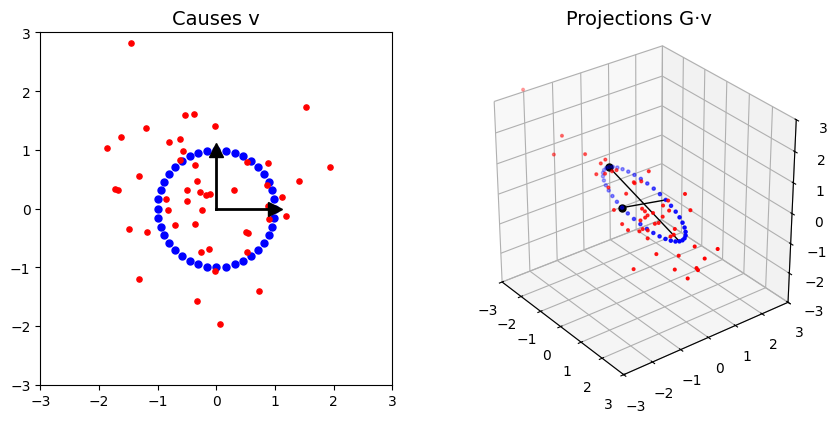

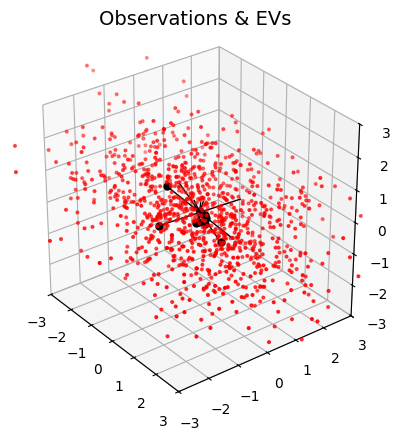

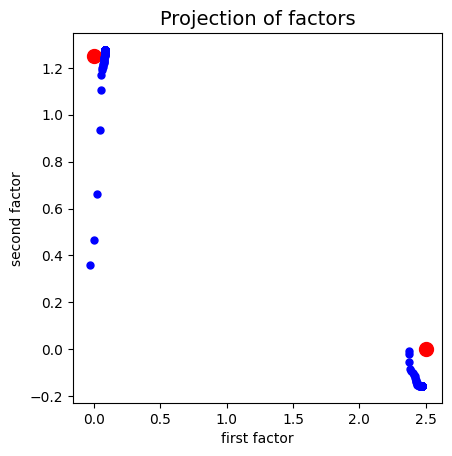

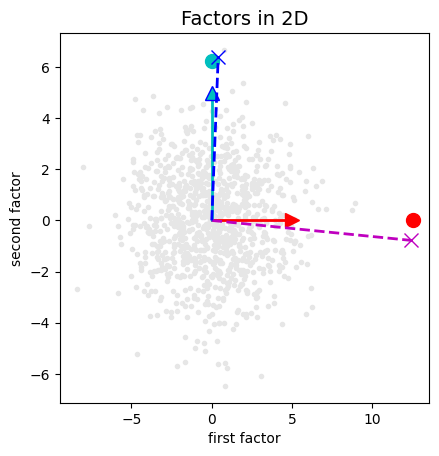

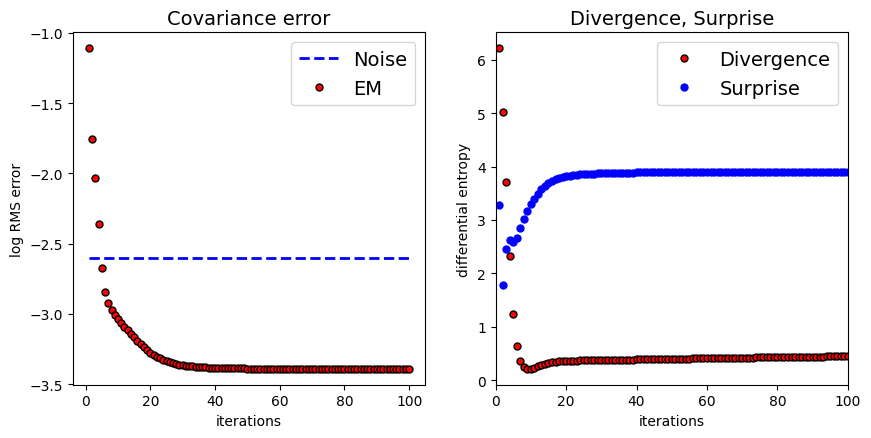

In [ ]:
# @title EM for Factor Analysis {"vertical-output":true,"display-mode":"form"}

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import linalg
from ipywidgets import interact

def my_scatter_plot_2d(u, clr, wdth):
    """Plot 2D scatter plot."""
    plt.plot(u[0, :], u[1, :], clr + 'o', markerfacecolor=clr, markersize=wdth * 5)

def my_scatter_plot_3d(u, clr, wdth, ax):
    """Plot 3D scatter plot."""
    ax.scatter(u[0, :], u[1, :], u[2, :], c=clr, marker='o', s=wdth * 5)

def factor_model_with_orthogonal_means(n_v, n_u):
    """Generate orthogonal factor model."""
    u = np.random.normal(0, 1, (n_u, 10))
    c = u @ u.T / 9
    d, x = linalg.eigh(c)
    idx = np.argsort(d)[::-1]
    e = x[:, idx[:n_v]]
    lambda_ = np.diag([2.5, 1.25])
    g = e @ lambda_
    return g, e, lambda_

def orthogonal_factors(g_new):
    """Orthogonalize factors."""
    n_v = g_new.shape[1]
    d, f = linalg.eigh(g_new @ g_new.T)
    idx = np.argsort(d)[::-1]
    f = f[:, idx]
    d = d[idx]
    l = np.diag(np.sqrt(d))
    g_orth = np.real(f @ l)[:, :n_v]
    return g_orth

def align_factors(g_new, g_old):
    """Align factors with previous factors."""
    n_v = g_new.shape[1]
    p = g_old.T @ g_new
    for i in range(n_v):
        if p[i, i] < 0:
            g_new[:, i] = -g_new[:, i]
    return g_new

def MakeSquarePlot( plt ):
    (xmin,xmax,ymin,ymax) = plt.gca().axis()
    xsize = xmax - xmin
    ysize = ymax - ymin
    plt.gca().set_aspect(xsize/ysize)

def track_progress(u_obs, g, sigma, w, psi, g_tru, sigma_tru, w_tru, psi_tru):
    """Compute divergence, surprise, and lower bound metrics."""
    n_u, n_v = g.shape
    inv_psi_tru = linalg.inv(psi_tru)
    div = 0.5 * (
        np.log(linalg.det(psi_tru)) - np.log(linalg.det(psi)) - n_v +
        np.mean(np.sum((((w - w_tru) @ u_obs).T @ inv_psi_tru) * ((w - w_tru) @ u_obs).T, axis=1)) +
        np.trace(psi @ inv_psi_tru)
    )
    phi = g @ g.T + sigma
    phi_tru = g_tru @ g_tru.T + sigma_tru
    inv_phi = linalg.inv(phi)
    sur = 0.5 * (n_u * np.log(2 * np.pi) + np.sum(np.log(np.diag(phi))) + np.trace(phi_tru @ inv_phi))
    low = 0.5 * (n_u * np.log(2 * np.pi) + np.log(linalg.det(phi_tru)) + n_u)
    return div, sur, low

def factor_analysis_two():
    """Main function for factor analysis with EM."""

    n_v = 2
    nsample = 50
    v = np.random.normal(0, 1, (n_v, nsample))
    vax = np.diag(np.ones(n_v))
    ncircle = 40
    c = np.array([np.cos(2 * np.pi * np.arange(1, ncircle + 1) / ncircle),
                  np.sin(2 * np.pi * np.arange(1, ncircle + 1) / ncircle)])
    xl = [-3, 3]

    # Figure 1: Causes
    fig1 = plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    my_scatter_plot_2d(c, 'b', 1)
    my_scatter_plot_2d(v, 'r', 0.75)
    plt.plot([0, 1], [0, 0], 'k', linewidth=2)
    plt.plot([0, 0], [0, 1], 'k', linewidth=2)
    plt.plot(1, 0, 'k>', markerfacecolor='k', markersize=10)
    plt.plot(0, 1, 'k^', markerfacecolor='k', markersize=10)
    plt.xlim(xl)
    plt.ylim(xl)
    plt.gca().set_box_aspect(1)
    plt.box(True)
    plt.title('Causes v', fontsize=14)

    # Generative model
    n_u = 10
    g_true, e_true, lambda_true = factor_model_with_orthogonal_means(n_v, n_u)
    gax = g_true @ vax
    sigma_true = np.diag(np.abs(np.random.normal(0, 1.0, n_u)))
    inv_sigma_true = linalg.inv(sigma_true)
    psi_true = linalg.inv(np.diag(np.ones(n_v)) + g_true.T @ inv_sigma_true @ g_true)
    w_true = psi_true @ g_true.T @ inv_sigma_true
    c_true = g_true @ g_true.T + sigma_true
    g_next = c_true @ w_true.T @ linalg.inv(w_true @ c_true @ w_true.T + psi_true)
    sigma_next = np.diag(np.diag((np.eye(n_u) - g_true @ w_true) @ c_true @ (np.eye(n_u) - g_true @ w_true).T + g_true @ psi_true @ g_true.T))

    # Visualize projections
    ax = fig1.add_subplot(1, 2, 2, projection='3d')
    my_scatter_plot_3d(g_true @ v, 'r', 0.75, ax)
    my_scatter_plot_3d(g_true @ c, 'b', 1.0, ax)
    scale = 1
    for i in range(gax.shape[1]):
        ax.plot(scale * gax[0, i] * np.array([-1, 1]), scale * gax[1, i] * np.array([-1, 1]),
                scale * gax[2, i] * np.array([-1, 1]), 'k-', linewidth=1)
        ax.plot([scale * gax[0, i]], [scale * gax[1, i]], [scale * gax[2, i]], 'ko', markerfacecolor='k', markersize=5)
    ax.set_xlim(xl)
    ax.set_ylim(xl)
    ax.set_zlim(xl)
    ax.set_box_aspect([1, 1, 1])
    ax.set_title('Projections G·v', fontsize=14)
    ax.view_init(azim=-37.5, elev=30)


    # Generate observations
    nobs = 1000
    v = np.random.normal(0, 1, (n_v, nobs))
    u_mean_true = g_true @ v
    u_sigma_true = np.tile(np.diag(sigma_true), (nobs, 1)).T
    u_obs = np.random.normal(u_mean_true, u_sigma_true)
    c_obs = u_obs @ u_obs.T / (nobs - 1)
    d, v_eig = linalg.eigh(c_obs)
    idx = np.argsort(d)[::-1]
    d = d[idx]
    v_eig = v_eig[:, idx]
    v_eig = v_eig * np.sqrt(d)

    # Figure 2: Observations
    fig2 = plt.figure()
    ax = fig2.add_subplot(111, projection='3d')
    my_scatter_plot_3d(u_obs, 'r', 0.75, ax)
    scale = 1
    for i in range(n_u):
        ax.plot(scale * v_eig[0, i] * np.array([-1, 1]), scale * v_eig[1, i] * np.array([-1, 1]),
                scale * v_eig[2, i] * np.array([-1, 1]), 'k-', linewidth=1)
        ax.plot([scale * v_eig[0, i]], [scale * v_eig[1, i]], [scale * v_eig[2, i]], 'ko', markerfacecolor='k', markersize=5)
    ax.set_xlim(xl)
    ax.set_ylim(xl)
    ax.set_zlim(xl)
    ax.set_box_aspect([1, 1, 1])
    ax.set_title('Observations & EVs', fontsize=14)
    ax.view_init(azim=-37.5, elev=30)


    # Estimate covariance error
    nrepeat = 100
    c_i = np.full((nrepeat, n_u, n_u), np.nan)
    for i in range(nrepeat):
        v_i = np.random.normal(0, 1, (n_v, nobs))
        u_mean_true = g_true @ v_i
        u_i = np.random.normal(u_mean_true, u_sigma_true)
        c_i[i, :, :] = u_i @ u_i.T / (nobs - 1)
    esterror = np.sqrt(np.mean(np.var(c_i, axis=0)))

    # EM-based factor analysis
    g_ini, _, _ = factor_model_with_orthogonal_means(n_v, n_u)
    sigma_ini = np.diag(np.abs(np.random.normal(0, 2, n_u)))
    niter = 100
    error_i = np.full(niter, np.nan)
    div_i = np.full(niter, np.nan)
    sur_i = np.full(niter, np.nan)
    low_i = np.full(niter, np.nan)
    g_i = orthogonal_factors(g_ini)
    sigma_i = sigma_ini

    # Figure 3: EM progress
    fig3 = plt.figure()
    g_2d = e_true.T @ g_true
    plt.plot(g_2d[0], g_2d[1], 'ro', markerfacecolor='r', markersize=10)
    for i in range(niter):
        inv_sigma_i = linalg.inv(sigma_i)
        psi_i = linalg.inv(np.diag(np.ones(n_v)) + g_i.T @ inv_sigma_i @ g_i)
        w_i = psi_i @ g_i.T @ inv_sigma_i
        div_i[i], sur_i[i], low_i[i] = track_progress(u_obs, g_i, sigma_i, w_i, psi_i, g_true, sigma_true, w_true, psi_true)
        g_next = c_obs @ w_i.T @ linalg.inv(w_i @ c_obs @ w_i.T + psi_i)
        sigma_next = np.diag(np.diag((np.eye(n_u) - g_i @ w_i) @ c_obs @ (np.eye(n_u) - g_i @ w_i).T + g_i @ psi_i @ g_i.T))
        g_orth = orthogonal_factors(g_next)
        g_orth = align_factors(g_orth, g_true)
        error_i[i] = np.sqrt(np.mean((c_obs - g_orth @ g_orth.T - sigma_next)**2))
        g_i = g_orth
        sigma_i = sigma_next
        o_2d = e_true.T @ g_orth
        plt.plot(o_2d[0], o_2d[1], 'bo', markerfacecolor='b', markersize=5)
    plt.xlabel('first factor')
    plt.ylabel('second factor')
    MakeSquarePlot( plt )
    plt.title('Projection of factors', fontsize=14)


    # Figure 4: Factors in 2D
    u_2d = e_true.T @ u_obs
    g_2d = e_true.T @ g_true
    fig4 = plt.figure()
    plt.plot(u_2d[0, :], u_2d[1, :], '.', color=[0.9, 0.9, 0.9])
    plt.plot([0, 5], [0, 0], 'r', linewidth=2)
    plt.plot([0, 0], [0, 5], 'c', linewidth=2)
    plt.plot(5, 0, 'r>', markerfacecolor='r', markersize=10)
    plt.plot(0, 5, 'b^', markerfacecolor='c', markersize=10)
    plt.plot(5 * g_2d[0, 0], 5 * g_2d[1, 0], 'ro', linewidth=2, markersize=10)
    plt.plot(5 * g_2d[0, 1], 5 * g_2d[1, 1], 'co', linewidth=2, markersize=10)
    g_2d = e_true.T @ g_orth
    plt.plot(5 * np.array([0, g_2d[0, 0]]), 5 * np.array([0, g_2d[1, 0]]), 'm--', linewidth=2)
    plt.plot(5 * np.array([0, g_2d[0, 1]]), 5 * np.array([0, g_2d[1, 1]]), 'b--', linewidth=2)
    plt.plot(5 * g_2d[0, 0], 5 * g_2d[1, 0], 'mx', markersize=10, linewidth=2)
    plt.plot(5 * g_2d[0, 1], 5 * g_2d[1, 1], 'bx', markersize=10, linewidth=2)
    MakeSquarePlot( plt )
    plt.xlabel('first factor')
    plt.ylabel('second factor')
    plt.title('Factors in 2D', fontsize=14)


    # Figure 5: Convergence metrics
    fig5 = plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot([1, niter], [np.log(esterror)] * 2, 'b--', linewidth=2, label='Noise')
    plt.plot(np.arange(1, niter + 1), np.log(error_i), 'ko', markerfacecolor='r', markersize=5, label='EM')
    plt.legend(loc='upper right', fontsize=14)
    (xmin,xmax,ymin,ymax) = plt.gca().axis()
    xsize = xmax - xmin
    ysize = ymax - ymin
    plt.gca().set_aspect(xsize/ysize)
    plt.xlabel('iterations')
    plt.ylabel('log RMS error')
    plt.title('Covariance error', fontsize=14)

    plt.subplot(1, 2, 2)
    plt.plot(np.arange(1, niter + 1), div_i, 'ko', markerfacecolor='r', markersize=5, label='Divergence')
    plt.plot(np.arange(1, niter + 1), sur_i - low_i, 'bo', markerfacecolor='b', markersize=5, label='Surprise')
    plt.xlim([0, niter])
    plt.legend(loc='upper right', fontsize=14)
    MakeSquarePlot( plt )
    plt.xlabel('iterations')
    plt.ylabel('differential entropy')
    plt.title('Divergence, Surprise', fontsize=14)


    # Print final results
    #print("Observed covariance:\n", c_obs)
    #print("Estimated covariance (G_i*G_i' + Sigma_i):\n", g_i @ g_i.T + sigma_i)
    #print("Error:\n", c_obs - g_i @ g_i.T - sigma_i)
    #print("Divergence:\n", div_i)
    #print("Surprise:\n", sur_i)
    #print("Log RMS error:", np.log(np.sqrt(np.mean((c_obs - g_i @ g_i.T - sigma_i)**2))))

interact( factor_analysis_two() )

# **Points to note**

<br>

- More realistic causes exhibit variable statistics.

<br>

- This can be captured with *Factor analysis*.

<br>

- Factor models are useful for spiking data because neurons exibit different level of noise.

<br>

- Special cases of *Factor analysis* are *Principle component analysis (PCA)* and *Independent component analysis (ICA)*


# Caution: the best approach is rarely obvious!

Two commonly used approaches to study interactions among neurons are spike count correlation, which describes pairs of neurons, and dimensionality reduction (factor analysis), applied to a population of neurons.

Although both approaches have been used to study trial-to-trial neuronal variability correlated among neurons, they are difficult to relate directly.

Umankantha et al. establish mathematical and empirical
relationships between pairwise correlation and metrics of population-wide covariability based on dimensionality reduction.

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Theoretical-Neuroscience-I/main/Umankantha_2021.png" width="600">

<br>

[Umankantha et al., 2021, Bridging neuronal correlations and dimensionality reduction.  Neuron 109, 2740-54](https://www.sciencedirect.com/science/article/pii/S0896627321004694)

# **Next:**

# $\qquad\qquad$ **14. Free Energy**

# $\qquad\qquad$ **15. Principal Component Analysis**

# $\qquad\qquad$  **16. Independent Component Analysis**
